In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

from src.data.classification.generator import ClassificationDataGenerator
from src.data.common.base_generator import GeneratorConfig

# Hardware Check

In [6]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("No GPU detected. Training will proceed on CPU (this may be slow).")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060
GPU Memory: 7.61 GB


# Data generation

In [7]:
gen = ClassificationDataGenerator()
config = GeneratorConfig.Presets.balanced()

num_samples = 10000
X_spectra, y_labels = gen.generate_dataset(num_samples=num_samples, min_elements=1, max_elements=5, config=config, num_workers=12)

print(f"Generated data shape X_spectra: {X_spectra.shape}")
print(f"Generated data shape y_labels: {y_labels.shape}")

Starting parallel classification generation with 12 workers...


Parallel Classification Generation: 100%|██████████| 10000/10000 [07:03<00:00, 23.63it/s]


Generated data shape X_spectra: (10000, 600)
Generated data shape y_labels: (10000, 41)


# Train/Val/Test Split



In [8]:
indices = np.arange(num_samples)
np.random.shuffle(indices)
X_spectra = X_spectra[indices]
y_labels = y_labels.iloc[indices].reset_index(drop=True)

train_split = int(0.7 * num_samples)
val_split = int(0.85 * num_samples)

X_train, y_train = X_spectra[:train_split], y_labels[:train_split]
X_val, y_val     = X_spectra[train_split:val_split], y_labels[train_split:val_split]
X_test, y_test   = X_spectra[val_split:], y_labels[val_split:]

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 7000
Val size: 1500
Test size: 1500


# Experimental Grid & Training

In [14]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from src.models.classification.architectures import MLPClassifier, CNNClassifier, TransformerClassifier
from src.models.denoising.preprocessing import StandardScaler, MinMaxScaler, LogMinMaxScaler
from xgboost import XGBClassifier

preprocessing_strategies = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'LogMinMax': LogMinMaxScaler()
}

architectures = {
    # Machine Learning
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_jobs=-1), n_jobs=-1),    
    'AdaBoost': MultiOutputClassifier(AdaBoostClassifier(), n_jobs=-1),
    'XGBoost': MultiOutputClassifier(
        XGBClassifier(
            use_label_encoder=False, 
            eval_metric='logloss',
            tree_method='hist',   # Required for newer XGBoost versions to use GPU
            device='cuda'         # Tells it to use the GPU
        )
    ),

    # Deep Learning
    'MLP': MLPClassifier,
    'CNN': CNNClassifier,
    'Transformer': TransformerClassifier
}

results = {}
trained_models = {}

In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score
from src.models.classification.trainer import ClassificationTrainer
import torch

epochs = 100
batch_size = 64
patience = 15
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]

for prep_name, scaler in preprocessing_strategies.items():
    print(f"\n{'='*40}\nPreprocessing Strategy: {prep_name}\n{'='*40}")

    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    y_train_np = y_train.values.astype(np.float32)
    y_val_np = y_val.values.astype(np.float32)
    y_test_np = y_test.values.astype(np.float32)

    for arch_name, arch_item in architectures.items():
        print(f"--> Training: {arch_name}")

        if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
            model = arch_item
            model.fit(X_train_s, y_train_np)
            preds = (model.predict(X_test_s) > 0.5).astype(int)
            history = None

        else:
            model = arch_item(input_dim=input_dim, num_classes=num_classes)
            trainer = ClassificationTrainer(model=model)

            # Training
            history = trainer.train(
                X_train_s, y_train_np,
                X_val_s, y_val_np,
                epochs=epochs,
                batch_size=batch_size,
                patience=patience
            )

            model.eval()
            with torch.no_grad():
                X_test_t = torch.FloatTensor(X_test_s).to(trainer.device)
                raw_preds = model(X_test_t).cpu().numpy()
                preds = (raw_preds > 0.5).astype(int)

        f1 = f1_score(y_test_np, preds, average='weighted', zero_division=0)
        precision = precision_score(y_test_np, preds, average='weighted', zero_division=0)
        recall = recall_score(y_test_np, preds, average='weighted', zero_division=0)

        results[f"{prep_name}_{arch_name}"] = {
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'history': history,
        }
        trained_models[f"{prep_name}_{arch_name}"] = (model, scaler)
        print(f"F1-Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")


Preprocessing Strategy: Standard
--> Training: RandomForest
F1-Score: 0.7995 | Precision: 0.9848 | Recall: 0.7292
--> Training: AdaBoost
F1-Score: 0.8142 | Precision: 0.9049 | Recall: 0.7770
--> Training: XGBoost
F1-Score: 0.8691 | Precision: 0.9593 | Recall: 0.8237
--> Training: MLP


Training:  24%|██▍       | 24/100 [00:03<00:09,  7.91it/s, train_loss=0.0610, val_loss=0.1316]


Early stopping triggered at epoch 25
F1-Score: 0.7320 | Precision: 0.9351 | Recall: 0.6415
--> Training: CNN


Training:  27%|██▋       | 27/100 [00:04<00:11,  6.54it/s, train_loss=0.0530, val_loss=0.0929]


Early stopping triggered at epoch 28
F1-Score: 0.7910 | Precision: 0.9597 | Recall: 0.7203
--> Training: Transformer


...

Early stopping triggered at epoch 50
F1-Score: 0.7542 | Precision: 0.9494 | Recall: 0.6751
--> Training: CNN


Training:  66%|██████▌   | 66/100 [00:09<00:04,  7.32it/s, train_loss=0.0631, val_loss=0.0825]


Early stopping triggered at epoch 67
F1-Score: 0.7979 | Precision: 0.9719 | Recall: 0.7267
--> Training: Transformer


Training:  82%|████████▏ | 82/100 [10:54<02:23,  7.98s/it, train_loss=0.0657, val_loss=0.1330]


Early stopping triggered at epoch 83
F1-Score: 0.7141 | Precision: 0.9299 | Recall: 0.6295


# Training Loss Visualization

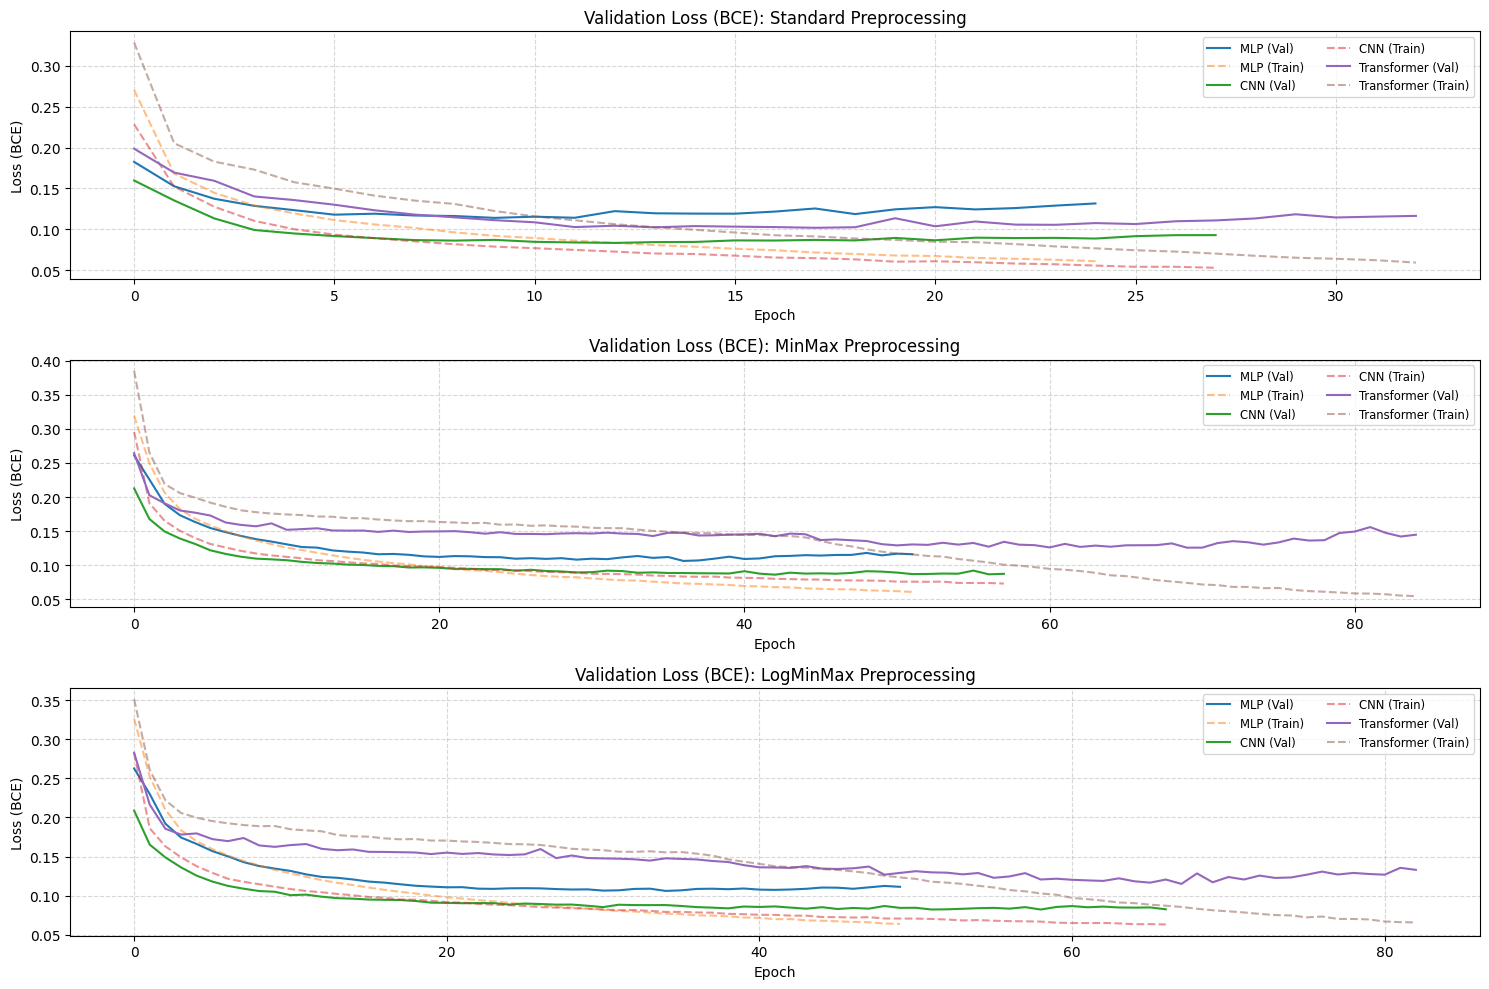

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plot_idx = 1
for prep_name in preprocessing_strategies.keys():
    plt.subplot(len(preprocessing_strategies), 1, plot_idx)

    for arch_name in architectures.keys():
        key = f"{prep_name}_{arch_name}"
        if key in results:
            history = results[key]['history']

            if history is not None:
                plt.plot(history['val_loss'], label=f"{arch_name} (Val)")
                plt.plot(history['train_loss'], linestyle='--', alpha=0.5, label=f"{arch_name} (Train)")

    plt.title(f"Validation Loss (BCE): {prep_name} Preprocessing")
    # plt.yscale('log')

    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCE)")
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plot_idx += 1

plt.tight_layout()
plt.show()

# Evaluation & Visualization

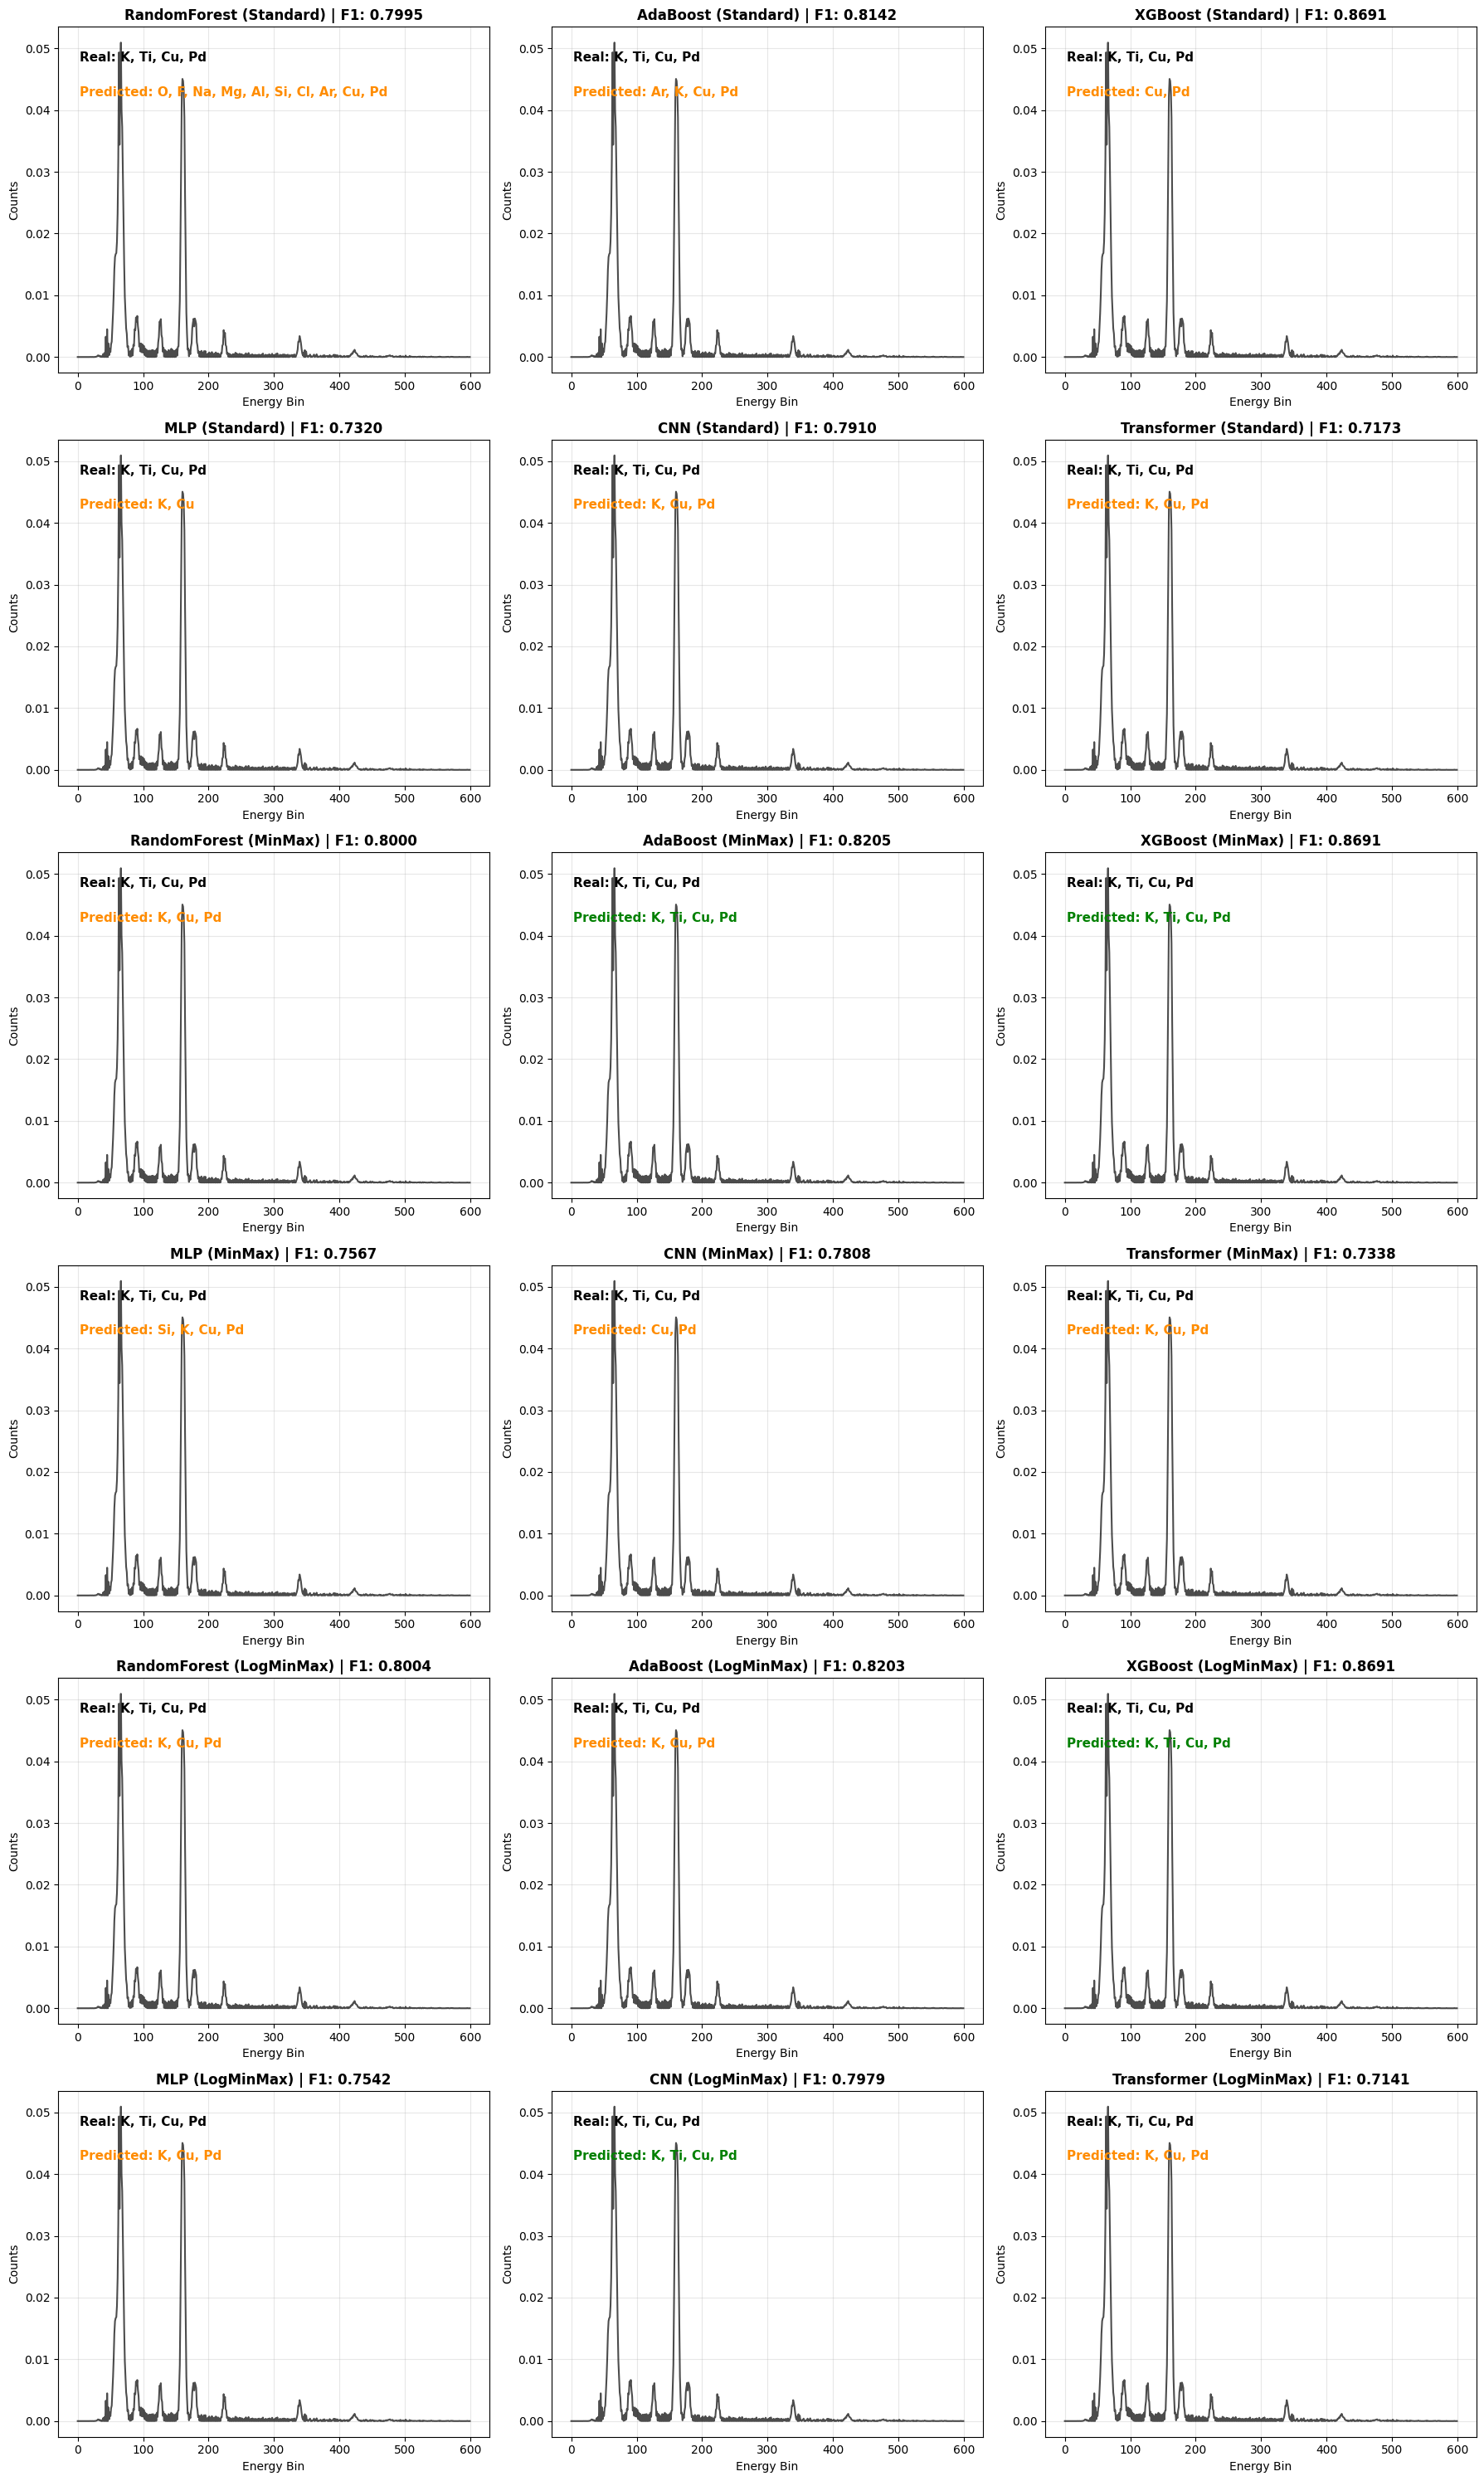

In [17]:
import matplotlib.pyplot as plt
import torch
import math

sample_idx = np.random.randint(0, len(X_test))
test_spectrum = X_test[sample_idx:sample_idx+1]
test_labels_true = y_test.iloc[sample_idx]

true_elements = test_labels_true.index[test_labels_true == 1].tolist()
true_text = f"Real: {', '.join(true_elements)}"

n_models = len(trained_models)
cols = 3
rows = math.ceil(n_models / cols)

plt.figure(figsize=(18, 5 * rows))

for i, key in enumerate(trained_models.keys()):
    model, scaler = trained_models[key]
    prep_name, arch_name = key.split('_')[0], key.split('_')[1]

    scaled_input = scaler.transform(test_spectrum)

    if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
        pred_binary = model.predict(scaled_input)[0]
    else:
        model.eval()
        with torch.no_grad():
            device = next(model.parameters()).device
            tensor_input = torch.FloatTensor(scaled_input).to(device)
            pred_binary = (model(tensor_input).cpu().numpy()[0] > 0.5).astype(int)

    pred_elements = y_test.columns[pred_binary == 1].tolist()
    pred_text = f"Predicted: {', '.join(pred_elements) if pred_elements else 'No elements'}"

    if set(true_elements) == set(pred_elements):
        text_color = 'green'
    elif set(true_elements).intersection(pred_elements):
        text_color = 'darkorange'
    else:
        text_color = 'red'

    plt.subplot(rows, cols, i+1)
    plt.plot(test_spectrum[0], color='black', alpha=0.7)

    f1_val = results[key]['f1_score']
    plt.title(f"{arch_name} ({prep_name}) | F1: {f1_val:.4f}", fontsize=12, fontweight='bold')

    plt.text(0.05, 0.90, true_text, transform=plt.gca().transAxes, fontsize=11, fontweight='bold')
    plt.text(0.05, 0.80, pred_text, transform=plt.gca().transAxes, fontsize=11, fontweight='bold', color=text_color)

    plt.xlabel("Energy Bin")
    plt.ylabel("Counts")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

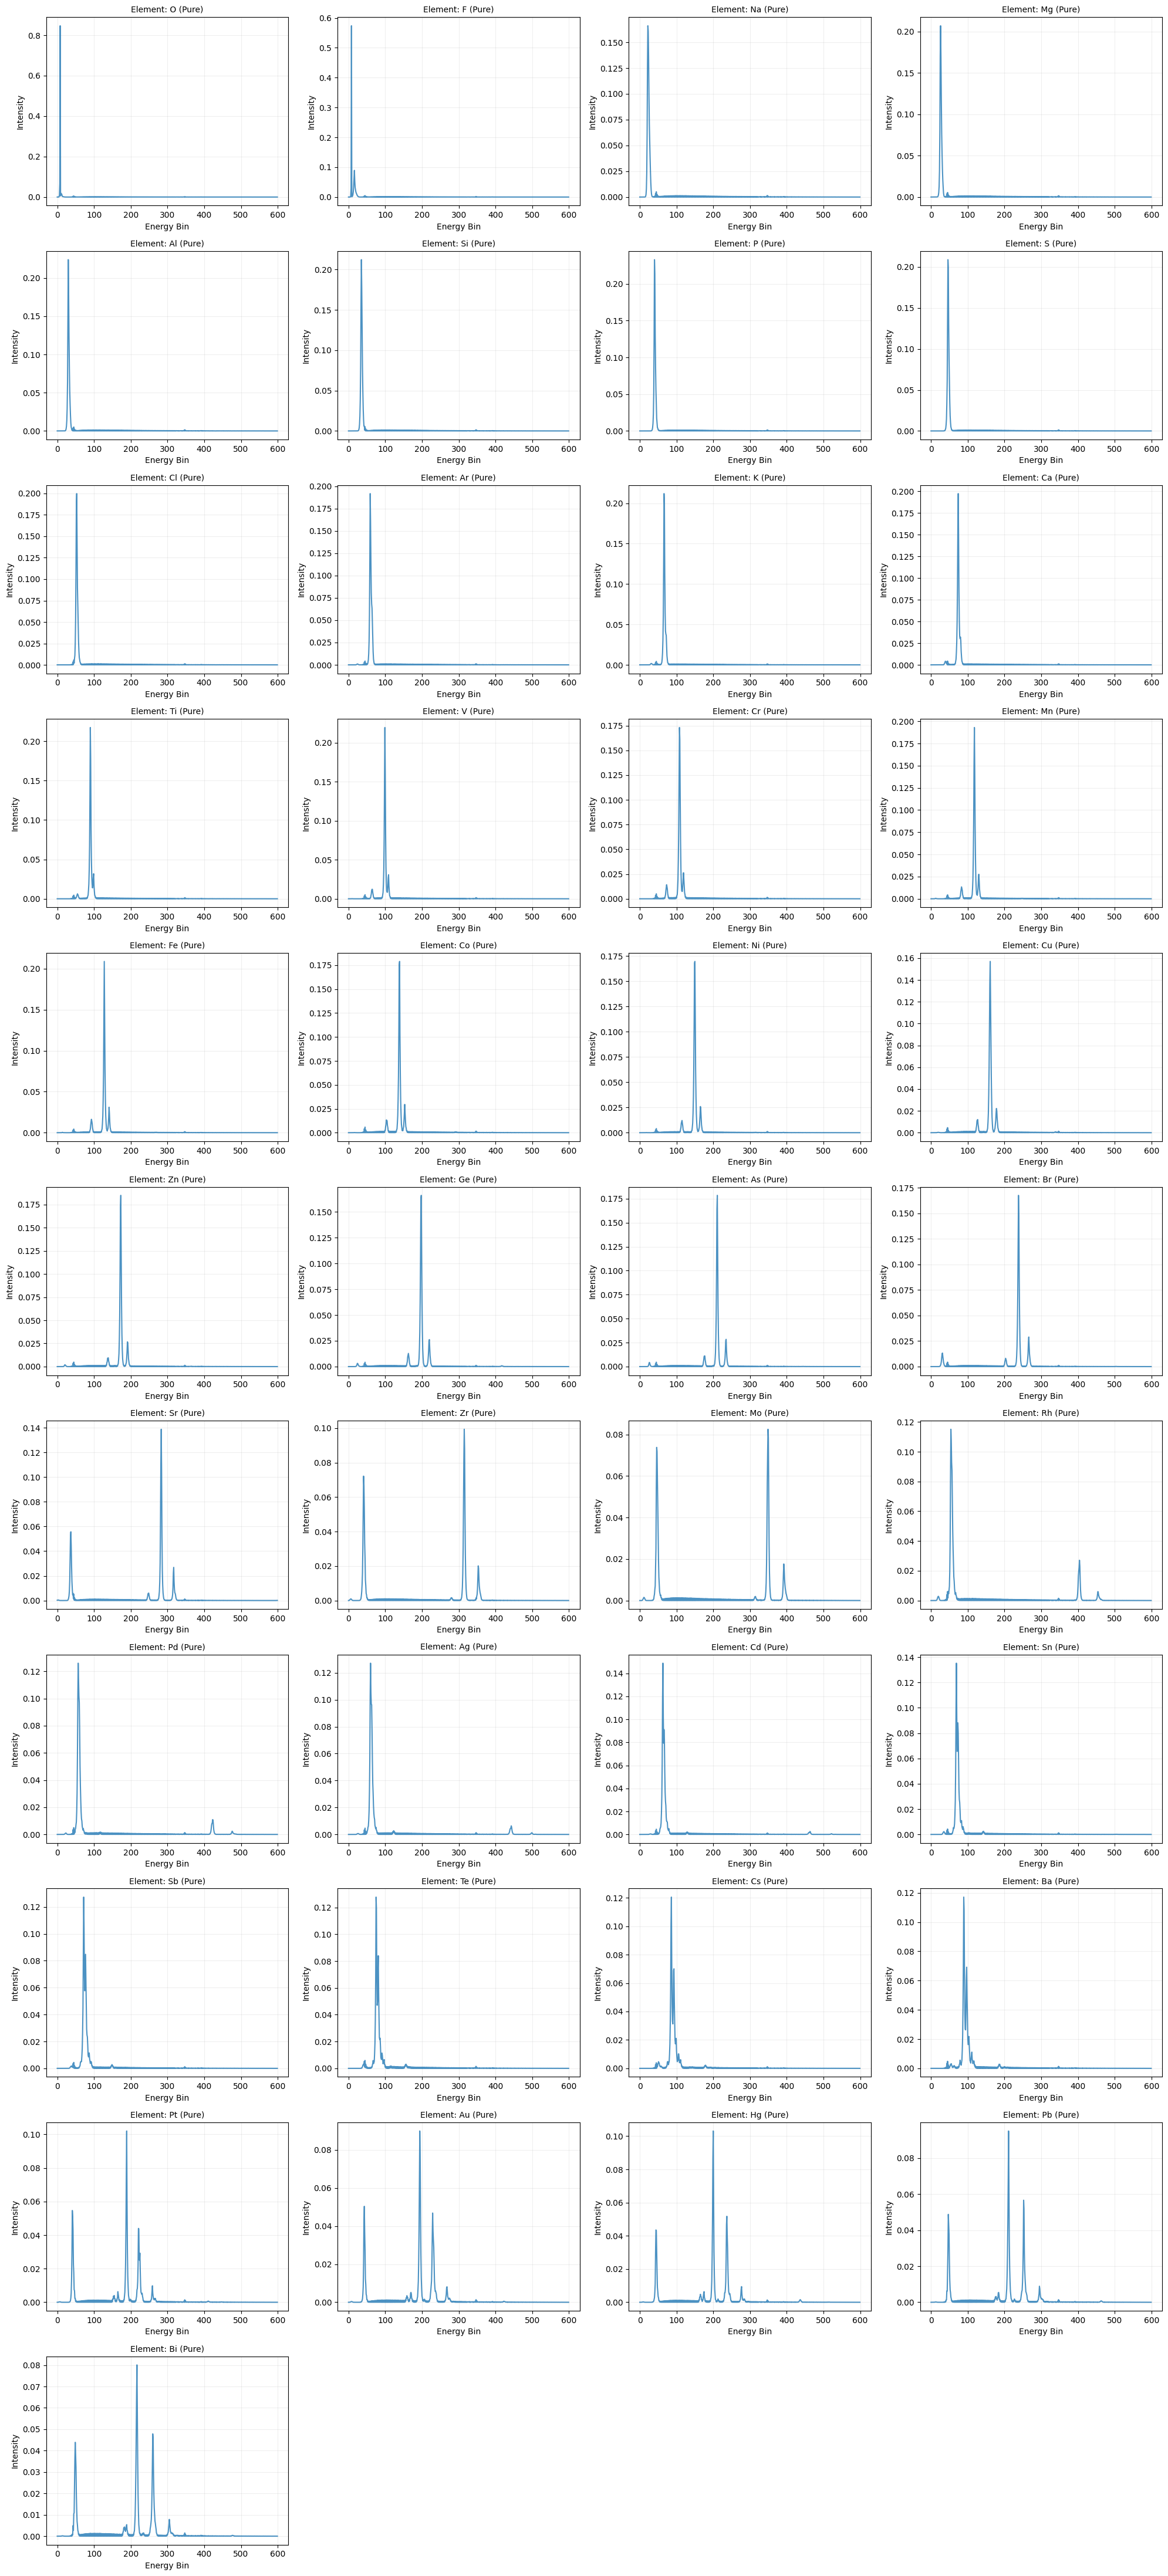

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_element_spectra(X, y, columns_per_row=4):
    elements = y.columns
    num_elements = len(elements)
    rows = math.ceil(num_elements / columns_per_row)
    plt.figure(figsize=(20, 4 * rows))

    for i, element in enumerate(elements):
        # Create a mask to find "pure" samples (where ONLY this element is present).
        pure_mask = (y[element] == 1) & (y.sum(axis=1) == 1)

        if pure_mask.any():
            spectra = X[pure_mask]
            title_suffix = "(Pure)"
        else:
            spectra = X[y[element] == 1]
            title_suffix = "(Mixed)"

        mean_spectrum = np.mean(spectra, axis=0)

        plt.subplot(rows, columns_per_row, i + 1)
        plt.plot(mean_spectrum, color='tab:blue', alpha=0.8)

        plt.title(f"Element: {element} {title_suffix}", fontsize=10)
        plt.xlabel("Energy Bin")
        plt.ylabel("Intensity")
        plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_element_spectra(X_spectra, y_labels)

# Comparative Results

In [19]:
import pandas as pd

summary_data = []
for key, metrics in results.items():
    parts = key.split('_')
    prep = parts[0]
    arch = parts[1]

    summary_data.append({
        'Preprocessing': prep,
        'Architecture': arch,
        'F1-Score': metrics['f1_score'],
        'Precision': metrics.get('precision', 0.0),
        'Recall': metrics.get('recall', 0.0)
    })

df_results = pd.DataFrame(summary_data).sort_values(by='F1-Score', ascending=False)

print("Model Performance Summary (Best to Worst by F1-Score):")
display(df_results.style.format({
    'F1-Score': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}'
}).background_gradient(subset=['F1-Score'], cmap='viridis'))

Model Performance Summary (Best to Worst by F1-Score):


,Preprocessing,Architecture,F1-Score,Precision,Recall
2,Standard,XGBoost,0.8691,0.9593,0.8237
8,MinMax,XGBoost,0.8691,0.9589,0.8243
14,LogMinMax,XGBoost,0.8691,0.9589,0.8243
7,MinMax,AdaBoost,0.8205,0.9151,0.7821
13,LogMinMax,AdaBoost,0.8203,0.9088,0.7830
1,Standard,AdaBoost,0.8142,0.9049,0.7770
12,LogMinMax,RandomForest,0.8004,0.9618,0.7314
6,MinMax,RandomForest,0.8000,0.9600,0.7305
0,Standard,RandomForest,0.7995,0.9848,0.7292
16,LogMinMax,CNN,0.7979,0.9719,0.7267
